# Simple example on how to perform and interpret privacy risks evaluation

This is an example on how that show a how to create a very simple AI/ML model with generic data. Once the model is trained, it is wrapped with the `Target` class to perform simulated attacks and generated a report from the attacks.

For the purpose of training, this example shows a high risk model, which under most circumstances will not be egressed from a TRE.

## Installation 

For this example, we will install all the necessary python packages within this notebook. Ideally, a virtual environment should be created (conda, anaconda, venv, etc.) and install all the packages within it.

If you already have one, and have all the following packages installed, skip the next cell. Activate that environment and run the Jupyter notebook within it. 

Otherwise, uncomment and run the cell below. Note that the installation can take several minutes.

In [1]:
#%pip install sacroml==1.4.3

## Loading modules

Load all the necessary modules for this example.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sacroml.attacks.structural_attack import StructuralAttack
from sacroml.attacks.likelihood_attack import LIRAAttack
from sacroml.attacks.worst_case_attack import WorstCaseAttack
from sacroml.attacks.attribute_attack import AttributeAttack
from sacroml.attacks.target import Target

# Create a dummy model

First load data, then split it into training and test sets with a minimum of 30% of data for testing. This is essential for 2 reason: (i) to ensure model evaluation and (ii) to enable disclosure control. Without this split models cannot be tested and will not be egressed from a TRE.

Normally, the data is first split into train and test, then both groups are processed in the same manner. For simplicity in this example, we skip the processing step.

In [3]:
# Load dataset
random_state = 4
dataset = load_breast_cancer()
X = dataset.data  # shape (n_samples, n_features)
y = dataset.target 

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3,
                                                    random_state=random_state,   # to make the model reproducible
                                                    stratify=y)                  # split label groups evenly

In this example we create a Random Forest model.

In [4]:
# Fit model
model = RandomForestClassifier(min_samples_split=2, min_samples_leaf=1)  # set hyperparameters
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Privacy risk assessment

AI/ML risk assessment consist of 2 levels of checks: (i) unintentional leakage, (ii) data leakage under malicious attacks.

## The *"Target"* object

Wrap the model, the train and target data and labels with the Target class. This enables a faster and esier option to evaluate the privacy risks of the model created.

The Target object contains at least the model, the train and test data and their corresponding labels. This data is the one used to train and test or evaluate the model (and not the raw data). This object can be saved. For example, a TRE researcher during the egress request could create this object and save it. Then the output checker can easily run the appropiate checks in a more straigthforward manner.

In [5]:
# Wrap model and data
target = Target(
    model=model,
    dataset_name="breast cancer",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)

target.save("output_dir") # save the target object in the output_dir.

## Unintentional leakage check

Sometimes AI/ML models configurations can immediately lead to potential data leakage. And can be dependent on dataset and pre-processing pipeline. It is vital to ensure the model to be egressed passes this first line of checks successfully.

### Structural privacy risks

The structural attacks is an assessment of privacy risks. The risks assessed are equivalent to the traditional statitical disclosure control. It checks for structural issues with the model that can lead to potential data breaches. It is based on the static structure of a model. Performs structural privacy risk assessments on trained AI/ML models. This assessment is based on model architecture and hyperparameters, aligned with TRE risk appetite for 'traditional' outputs.

It includes checks for: 
- Residual Degrees of freedom 
- Complexity risk 
- uses Equivalence class analysis to identify risks of K-anonymity and Class disclosure (partitions of decision space with zero probability for some labels) 
- Reidentification through small groups (partitions of decision space with some groups below the cell count threshold).

First need to check that your model is supported to run the structural privacy risk assessment. (In fact, this type of check works in all the implemented attacks.)

In [6]:
StructuralAttack.attackable(target)

INFO:sacroml.attacks.structural_attack:Class of module is <class 'sklearn.ensemble._forest.RandomForestClassifier'> 


True

If True, then run the structural privacy risk assessment. This should run previous to any other simulated attacks. It detects immediate red flags that should be dealt with if detected. Once this check is all good, you can move to the next level of risk assessment.

In [7]:

structural_attack = StructuralAttack(output_dir="structural_privacy_risk_example")
structural_attack.attack(target)

INFO:acro:version: 0.4.11
INFO:acro:config: {'safe_threshold': 10, 'safe_dof_threshold': 10, 'safe_nk_n': 2, 'safe_nk_k': 0.9, 'safe_pratio_p': 0.1, 'check_missing_values': False, 'survival_safe_threshold': 10, 'zeros_are_disclosive': True}
INFO:acro:automatic suppression: False
INFO:sacroml.attacks.structural_attack:Thresholds for count 10 and DoF 10
INFO:sacroml.attacks.structural_attack:Class of module is <class 'sklearn.ensemble._forest.RandomForestClassifier'> 
INFO:sacroml.attacks.structural_attack:Samples=398, Parameters=4294, DoF=-3896
INFO:sacroml.attacks.structural_attack:Smallest equivalence class size (k-anonymity) is 1
INFO:sacroml.attacks.attack:Generating report
INFO:sacroml.attacks.attack:Writing report: structural_privacy_risk_example\report.json structural_privacy_risk_example\report.pdf


{'log_id': 'db621b79-5cf3-43d4-95f9-6f540767eab8',
 'log_time': '06/05/2026 12:26:52',
 'metadata': {'sacroml_version': '1.4.3',
  'attack_name': 'Structural Attack',
  'attack_params': {'output_dir': 'structural_privacy_risk_example',
   'write_report': True,
   'risk_appetite_config': 'default',
   'report_individual': False,
   'attack_name': 'Structural Attack',
   'safe_threshold': 10,
   'safe_dof_threshold': 10},
  'global_metrics': {'test_acc': 0.9532163742690059,
   'train_acc': 1.0,
   'generalisation_error': -0.04678362573099415,
   'gen_error_risk': np.False_,
   'unnecessary_risk': True,
   'dof_risk': True,
   'k_anonymity_risk': True,
   'class_disclosure_risk': True,
   'smallgroup_risk': True,
   'details': None},
  'target_model': 'RandomForestClassifier',
  'target_model_params': {},
  'target_train_params': {}},
 'attack_experiment_logger': {'attack_instance_logger': {'instance_0': {'test_acc': 0.9532163742690059,
    'train_acc': 1.0,
    'generalisation_error': -0

The summary of results is contained in the section "global metrics". Any metric showing as "True" means it is a risk, if "False" that particular risk is negligible.

For this example, the results shows that the models passes the checks for:
- Generalisation error, meaning that will generalise well in unseen data.

The assessment shows some potential risks:
- The model could potentially reveal data belonging to small groups of records (K anonymity and class disclosure risk).
- The model is likely to reveal data from small group counts (lowvals_cd_risk).
- The model is at risk of memorisation some data samples. It is overly complex for the amount of training data (measured by e.g. degrees of freedom, and unnecessary risk).

The researcher should think of modifying hyperparameters, a different type of simplier algorithm. However, in cases where the dataset is small is likely that traditional statistical methods will be more appropiate.

### Attribute inference privacy risk

When some columns of your data can contain particular sensitive information, it is possible to estimate the risk of it being disclosed. 

The attribute inference is an estimation of how easy is to disclose each attribute from a particular dataset. The TRE should then discuss the importance of the attribute at risk of being disclosed compared to the corresponding level of sensitive information it contains.

This assessment need the raw data and features names. In this example, the data was not processed.


In [8]:
# Add raw data to the Target object
target.X_train_orig = X_train
target.y_train_orig = y_train
target.X_test_orig = X_test
target.y_test_orig = y_test

# Add features names
for i, feature_name in enumerate(dataset.feature_names):
    target.add_feature(
        name = feature_name,
        indices = i,
        encoding = 'enc'
    )

INFO:sacroml.attacks.attribute_attack:Running attribute inference attack
INFO:sacroml.attacks.attribute_attack:Attacking dataset: breast cancer
INFO:sacroml.attacks.attribute_attack:Attacking categorical attributes...
INFO:sacroml.attacks.attribute_attack:Attacking quantitative attributes...
INFO:sacroml.attacks.attack:Generating report
INFO:sacroml.attacks.attack:Writing report: attriuteInference_output_example\report.json attriuteInference_output_example\report.pdf


{'log_id': 'b4e155a2-d0e1-4d25-9744-d1d10efb14b2',
 'log_time': '06/05/2026 12:31:51',
 'metadata': {'sacroml_version': '1.4.3',
  'attack_name': 'Attribute inference attack',
  'attack_params': {'output_dir': 'attriuteInference_output_example',
   'write_report': True,
   'n_cpu': 1},
  'global_metrics': {},
  'target_model': 'RandomForestClassifier',
  'target_model_params': {},
  'target_train_params': {}},
 'attack_experiment_logger': {'attack_instance_logger': {'instance_0': {'name': 'breast cancer',
    'categorical': [],
    'quantitative': [{'name': np.str_('mean radius'),
      'train': 0.05527638190954774,
      'test': 0.04678362573099415},
     {'name': np.str_('mean texture'),
      'train': 0.005025125628140704,
      'test': 0.0},
     {'name': np.str_('mean perimeter'),
      'train': 0.10804020100502512,
      'test': 0.029239766081871343},
     {'name': np.str_('mean area'),
      'train': 0.05527638190954774,
      'test': 0.005847953216374269},
     {'name': np.str_

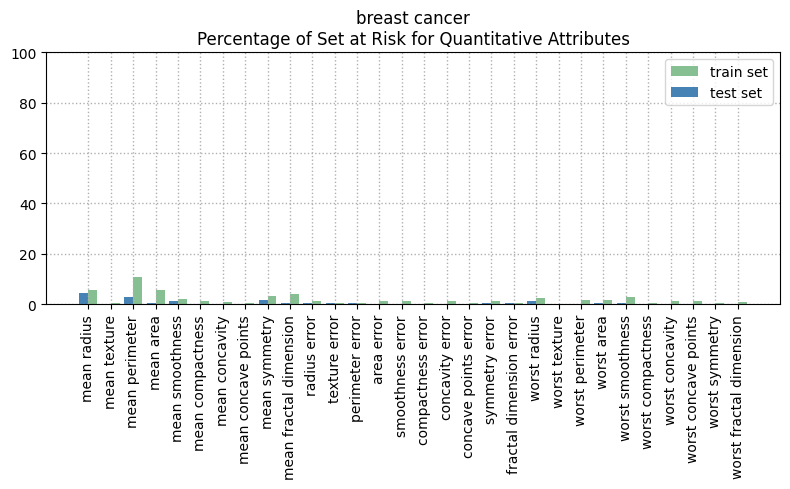

In [9]:
# Attribute inference attack
dir(AttributeAttack)
Attribute_attack = AttributeAttack(output_dir="attriuteInference_output_example", n_cpu=1)

Attribute_attack.attack(target)

The plot shows that some attributes are at higher risk of disclosure compared to others. However, this will always need a data and privacy experts to interpret correctly the results. 

Some might be at high risk but not contain any personal data, and so it probably will not have negative impact for egress, whereas more sentive information will require careful examination and evaluation of the disclosure risks.

## Evaluation of data leakage under malicious attack

Even if the first line of privacy checks are all low, there are other risks that must be evaluated previous to a model egress. Once models are released from the TRE they may become potential targets to malicious attackers. It is important to ensure the risk of data breach are minimised under such circumstances.

SACROM-ML has implemented simulated attacks to estimate privacy risks of the model under malicious attacks.

The Worst Case attack it is computationally cheap and generally easier to run compared to LiRA (see below). To be used as a quick baseline for membership inference, especially when LiRA can't be applied.

INFO:sacroml.attacks.worst_case_attack:Running main attack repetitions
INFO:sacroml.attacks.worst_case_attack:Sorting probabilities to leave highest value in first column
INFO:sacroml.attacks.worst_case_attack:Creating MIA data
INFO:sacroml.attacks.worst_case_attack:Rep 1 of 10 split 5
INFO:sacroml.attacks.worst_case_attack:Rep 2 of 10 split 25
INFO:sacroml.attacks.worst_case_attack:Rep 3 of 10 split 36
INFO:sacroml.attacks.worst_case_attack:Rep 4 of 10 split 49
INFO:sacroml.attacks.worst_case_attack:Rep 5 of 10 split 64
INFO:sacroml.attacks.worst_case_attack:Rep 6 of 10 split 81
INFO:sacroml.attacks.worst_case_attack:Rep 7 of 10 split 100
INFO:sacroml.attacks.worst_case_attack:Rep 8 of 10 split 121
INFO:sacroml.attacks.worst_case_attack:Rep 9 of 10 split 144
INFO:sacroml.attacks.worst_case_attack:Rep 10 of 10 split 169
INFO:sacroml.attacks.worst_case_attack:Finished simulating attacks
INFO:sacroml.attacks.worst_case_attack:Running dummy attack reps
INFO:sacroml.attacks.worst_case_atta

{'log_id': '4feb6c17-1a6b-4a19-b259-87a4e82be909',
 'log_time': '06/05/2026 12:31:55',
 'metadata': {'sacroml_version': '1.4.3',
  'attack_name': 'WorstCase attack',
  'attack_params': {'output_dir': 'worstCase_output_example',
   'write_report': True,
   'n_reps': 10,
   'reproduce_split': 5,
   'p_thresh': 0.05,
   'n_dummy_reps': 1,
   'train_beta': 1,
   'test_beta': 1,
   'test_prop': 0.2,
   'include_model_correct_feature': False,
   'sort_probs': True,
   'attack_model': 'sklearn.ensemble.RandomForestClassifier',
   'attack_model_params': None},
  'global_metrics': {'null_auc_3sd_range': '0.3219 -> 0.6781',
   'n_sig_auc_p_vals': 0,
   'n_sig_auc_p_vals_corrected': 0,
   'n_sig_pdif_vals': 1,
   'n_sig_pdif_vals_corrected': 0},
  'baseline_global_metrics': {'null_auc_3sd_range': '0.3219 -> 0.6781',
   'n_sig_auc_p_vals': 0,
   'n_sig_auc_p_vals_corrected': 0,
   'n_sig_pdif_vals': 0,
   'n_sig_pdif_vals_corrected': 0},
  'target_model': 'RandomForestClassifier',
  'target_model_

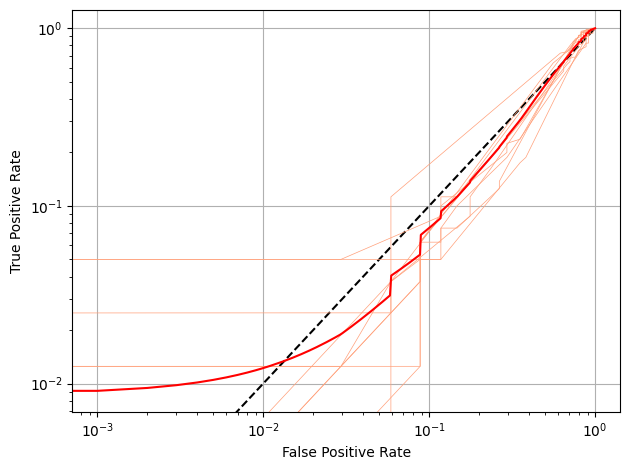

In [10]:
# Worst case attack
WorstCase_attack = WorstCaseAttack(output_dir="worstCase_output_example", n_reps=10)

WorstCase_attack.attack(target)

The plot shows a black dashed line, which represents a baseline if the attacker guessed completely randomly which data points belong to the training dataset. The orange and red lines are the different runs of this attacks (with different data splits for better estimation of the risk). If those lines are away from the black one, indicates risk of disclosure, as it is the case in this example.

### Likelyhood Ratio Attack (LiRA)

The most advanced and statistically strong attack. It trains many "shadow" models to learn subtle differences in how the model behaves on seen vs. unseen data, then uses a likelihood ratio test.

It estimated the capability of an attacker to correctly identify records (all the information to relating to one or more people) that was used during the training phase.

Where possible this attack should be run instead of the Worst Case.


INFO:sacroml.attacks.utils:new y_train has values and counts: (array([0, 1]), array([148, 250]))
INFO:sacroml.attacks.utils:new y_test has values and counts: (array([0, 1]), array([ 64, 107]))
INFO:sacroml.attacks.likelihood_attack:Running offline LiRA, fix_variance=False
INFO:sacroml.attacks.utils:Training shadow models
INFO:sacroml.attacks.utils:Found 1000 models previously trained
INFO:sacroml.attacks.likelihood_attack:Getting signals from 100 shadow models
INFO:sacroml.attacks.likelihood_attack:Computing scores
INFO:sacroml.attacks.likelihood_attack:Finished scenario
INFO:sacroml.attacks.attack:Generating report
INFO:sacroml.attacks.attack:Writing report: output_example\report.json output_example\report.pdf


{'log_id': '6a6e015b-9ffa-4b15-b399-e5f4c16974ed',
 'log_time': '06/05/2026 12:32:08',
 'metadata': {'sacroml_version': '1.4.3',
  'attack_name': 'LiRA Attack',
  'attack_params': {'output_dir': 'output_example',
   'write_report': True,
   'n_shadow_models': 100,
   'p_thresh': 0.05,
   'mode': 'offline',
   'fix_variance': False,
   'report_individual': False},
  'global_metrics': {'PDIF_sig': 'Significant at p=0.05',
   'AUC_sig': 'Significant at p=0.05',
   'null_auc_3sd_range': '0.4207446718814698 -> 0.5792553281185302'},
  'target_model': 'RandomForestClassifier',
  'target_model_params': {},
  'target_train_params': {}},
 'attack_experiment_logger': {'attack_instance_logger': {'instance_0': {'TPR': 0.69095477,
    'FPR': 0.42690058,
    'FAR': 0.20977011,
    'TNR': 0.57309942,
    'PPV': 0.79022989,
    'NPV': 0.44343891,
    'FNR': 0.30904523,
    'ACC': 0.65553603,
    'F1score': 0.73726542,
    'Advantage': 0.2640541900000001,
    'AUC': 0.66516794,
    'P_HIGHER_AUC': np.fl

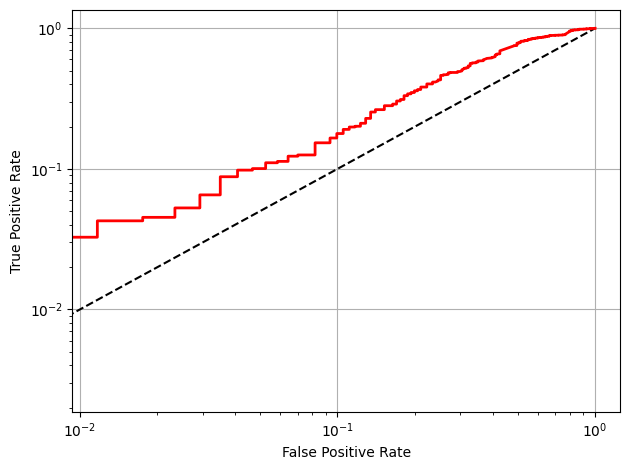

In [11]:
# Create an attack object and run the attack
# ensure Structural attack is also created 
attack = LIRAAttack(n_shadow_models=100, output_dir="output_example")

attack.attack(target)

The LiRA results shows that:
- General metrics (average):
    - Thresholds can be set on risk appetite TRE-project dependant.
    - The AUC of the attack is significant.
- Metrics designed for disclosure control
    - The metrics PDIF, designed for disclosure risk, is significant. This means that some records will be disclosed under malicious attack.
    - The metric Advantage measures how successful attacks can be. Results between 0.1 and 0.2 indicate borderline successful attacks, and above 0.2 indicate the attacker is sucessful.
    - The metric TPR at specific low FPR is high, also signals that some records will be disclosed under malicious attack.

# Conclusions

The model is wrapped in the "Target" object, which enables a faster and easier assessment of the privacy risks.

This model is high risk and is very likely that a data breach can occur. It failed both assessments, the structural risks and the simulated malicious attacks.

The model hyperparameters should be changed prior requesting a model egress or if it has been requested, the TRE operator will refuse the egress of the model.